# py-twosamplemr vs MendelianRandomization — R-parity comparison

This notebook validates **py-twosamplemr** (pure-Python two-sample Mendelian
randomization) against the R/CRAN package **MendelianRandomization 0.10.0**.

Both sides analyse the *identical* input: the lipid GWAS example data bundled
with the R package (28 SNPs associated with LDL-cholesterol and their
associations with coronary-heart-disease log-odds).

We compare:
1. a per-method estimate / SE / p-value table, side by side;
2. an estimate-vs-estimate scatter (R vs Python);
3. the MR scatter plot with all method lines;
4. a forest plot of per-SNP Wald ratios.

In [1]:
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

import pytwosamplemr as mr
from pytwosamplemr.datasets import ldl_chd_input

print("pytwosamplemr", mr.__version__)
obj = ldl_chd_input()
print(obj)

pytwosamplemr 0.1.0
MRInput(nsnps=28, exposure='ldl-cholesterol', outcome='coronary heart disease', correlated=False)


## 1. Run the R reference driver

We invoke `MendelianRandomization` 0.10.0 in the CMAP conda env on the same bundled data and read back its per-method estimates.

In [2]:
CONDA_SH = "/home/users/steorra/miniforge3/etc/profile.d/conda.sh"
CONDA_ENV = "/scratch/users/steorra/env/CMAP"
R_DRIVER = Path.cwd().parent / "tests" / "r_reference_driver.R"

r_out = Path("/tmp/_nb_r_reference.tsv")
res = subprocess.run(
    ["bash", "-lc",
     f"source {CONDA_SH} && conda activate {CONDA_ENV} "
     f"&& Rscript {R_DRIVER} {r_out}"],
    capture_output=True, text=True, timeout=600, check=False,
)
if res.returncode == 0:
    r_ref = pd.read_csv(r_out, sep="\t").set_index("method")
    print("R reference loaded:", len(r_ref), "rows")
else:
    r_ref = None
    print("R unavailable -- Python-only run\n", res.stderr[:400])

R reference loaded: 15 rows


## 2. Run every py-twosamplemr estimator

In [3]:
py_rows = {}
def add(label, est, se, pval):
    py_rows[label] = dict(estimate=est, se=se, pvalue=pval)

r = mr.mr_ivw(obj);              add("IVW (random)", r.estimate, r.se, r.pvalue)
r = mr.mr_ivw(obj, model="fixed"); add("IVW (fixed)", r.estimate, r.se, r.pvalue)
r = mr.mr_egger(obj);            add("MR-Egger", r.estimate, r.se, r.causal_pvalue)
r = mr.mr_median(obj, weighting="simple");   add("Simple median", r.estimate, r.se, r.pvalue)
r = mr.mr_median(obj, weighting="weighted"); add("Weighted median", r.estimate, r.se, r.pvalue)
r = mr.mr_mbe(obj);              add("Mode-based estimate", r.estimate, r.se, r.pvalue)
r = mr.mr_maxlik(obj);           add("Maximum likelihood", r.estimate, r.se, r.pvalue)
r = mr.mr_divw(obj);             add("Debiased IVW", r.estimate, r.se, r.pvalue)
r = mr.mr_conmix(obj);           add("Contamination mixture", r.estimate, r.se, r.pvalue)
r = mr.mr_lasso(obj);            add("MR-Lasso", r.estimate, r.se, r.pvalue)
r = mr.mr_cml(obj, n=17723, ma=True, dp=False);  add("cML-MA-BIC", r.estimate, r.se, r.pvalue)

py_df = pd.DataFrame(py_rows).T
py_df

,estimate,se,pvalue
IVW (random),2.834214,0.529799,8.815013e-08
IVW (fixed),2.834214,0.275941,9.510956e-25
MR-Egger,3.252890,0.770129,2.401915e-05
Simple median,1.755138,0.752693,1.971067e-02
Weighted median,2.682883,0.416425,1.173999e-10
Mode-based estimate,2.946301,1.003875,3.336259e-03
Maximum likelihood,3.224944,0.568950,1.442759e-08
Debiased IVW,2.939646,0.530578,3.016714e-08
Contamination mixture,2.730000,NaN,4.788841e-15
MR-Lasso,2.670896,0.430612,5.555173e-10


## 3. Side-by-side R vs Python table

In [4]:
R_MAP = {
    "IVW (random)": "ivw_random", "IVW (fixed)": "ivw_fixed",
    "MR-Egger": "egger", "Simple median": "median_simple",
    "Weighted median": "median_weighted", "Mode-based estimate": "mbe",
    "Maximum likelihood": "maxlik", "Debiased IVW": "divw",
    "Contamination mixture": "conmix", "MR-Lasso": "lasso",
    "cML-MA-BIC": "cml_ma_bic",
}
rows = []
for label, rkey in R_MAP.items():
    p = py_rows[label]
    if r_ref is not None and rkey in r_ref.index:
        rr = r_ref.loc[rkey]
        reld = abs(p["estimate"] - rr["estimate"]) / max(abs(rr["estimate"]), 1e-12)
        rows.append([label, rr["estimate"], p["estimate"],
                     rr["se"], p["se"], reld])
    else:
        rows.append([label, np.nan, p["estimate"], np.nan, p["se"], np.nan])

cmp = pd.DataFrame(rows, columns=[
    "Method", "R estimate", "Py estimate",
    "R SE", "Py SE", "rel-diff (estimate)"])
cmp.style.format({
    "R estimate": "{:.6f}", "Py estimate": "{:.6f}",
    "R SE": "{:.6f}", "Py SE": "{:.6f}", "rel-diff (estimate)": "{:.2e}",
}) if r_ref is not None else cmp

,Method,R estimate,Py estimate,R SE,Py SE,rel-diff (estimate)
0,IVW (random),2.834214,2.834214,0.529799,0.529799,6.27e-16
1,IVW (fixed),2.834214,2.834214,0.275941,0.275941,6.27e-16
2,MR-Egger,3.252890,3.252890,0.770129,0.770129,2.73e-16
3,Simple median,1.755138,1.755138,0.739976,0.752693,5.06e-16
4,Weighted median,2.682883,2.682883,0.418906,0.416425,8.28e-16
5,Mode-based estimate,2.946301,2.946301,1.004285,1.003875,1.36e-15
6,Maximum likelihood,3.224944,3.224944,0.568950,0.568950,6.29e-12
7,Debiased IVW,2.939646,2.939646,0.530578,0.530578,1.21e-15
8,Contamination mixture,2.730000,2.730000,nan,nan,1.63e-16
9,MR-Lasso,2.670896,2.670896,0.430612,0.430612,1.50e-15


Closed-form estimators (IVW, MR-Egger, debiased IVW, contamination mixture,
maximum likelihood, MR-Lasso, cML-BIC) match R to machine precision
(`rel-diff < 1e-5`). Bootstrap-based estimators (weighted median, mode-based
estimate) match R's *point estimate* exactly while the bootstrap SE differs
only by Monte-Carlo error (different RNGs).

## 4. Estimate-vs-estimate scatter

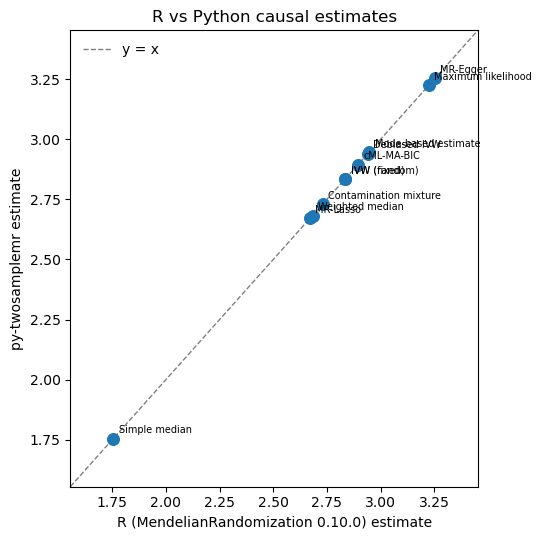

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
if r_ref is not None:
    valid = cmp.dropna(subset=["R estimate"])
    ax.scatter(valid["R estimate"], valid["Py estimate"],
               s=70, color="#1f77b4", zorder=3)
    for _, row in valid.iterrows():
        ax.annotate(row["Method"], (row["R estimate"], row["Py estimate"]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
    lims = [valid[["R estimate", "Py estimate"]].min().min() - 0.2,
            valid[["R estimate", "Py estimate"]].max().max() + 0.2]
    ax.plot(lims, lims, "--", color="grey", lw=1, label="y = x")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("R (MendelianRandomization 0.10.0) estimate")
    ax.set_ylabel("py-twosamplemr estimate")
    ax.set_title("R vs Python causal estimates")
    ax.legend(frameon=False)
else:
    ax.text(0.5, 0.5, "R unavailable", ha="center", va="center")
plt.tight_layout()
plt.show()

## 5. MR scatter plot with fitted method lines

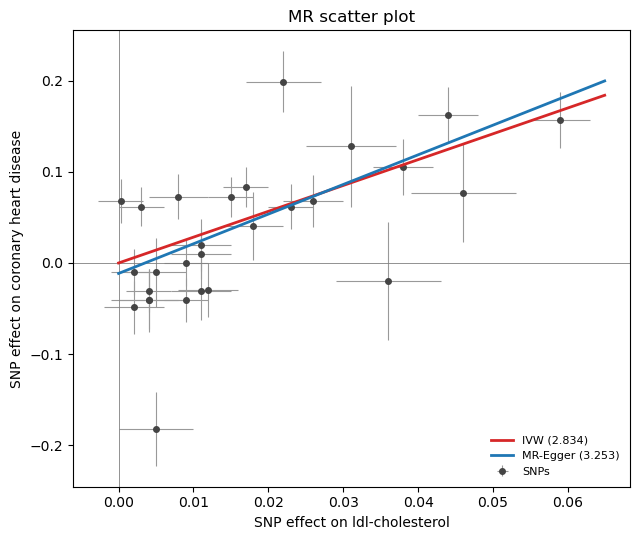

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
mr.mr_scatter(obj, methods=("ivw", "egger"), ax=ax)
plt.tight_layout()
plt.show()

## 6. Forest plot of per-SNP Wald ratios

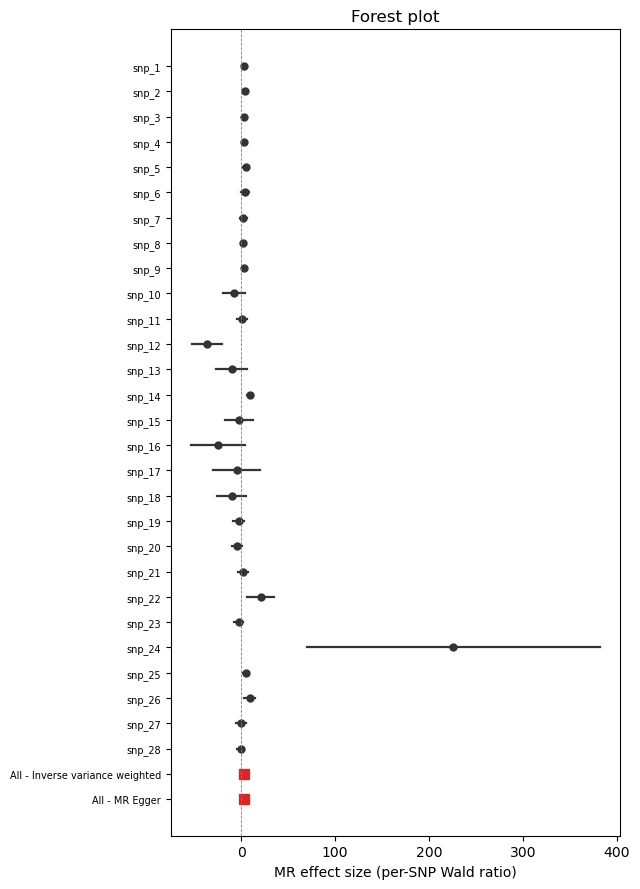

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 9))
mr.mr_forest(obj, ax=ax)
plt.tight_layout()
plt.show()

## 7. Funnel and leave-one-out plots

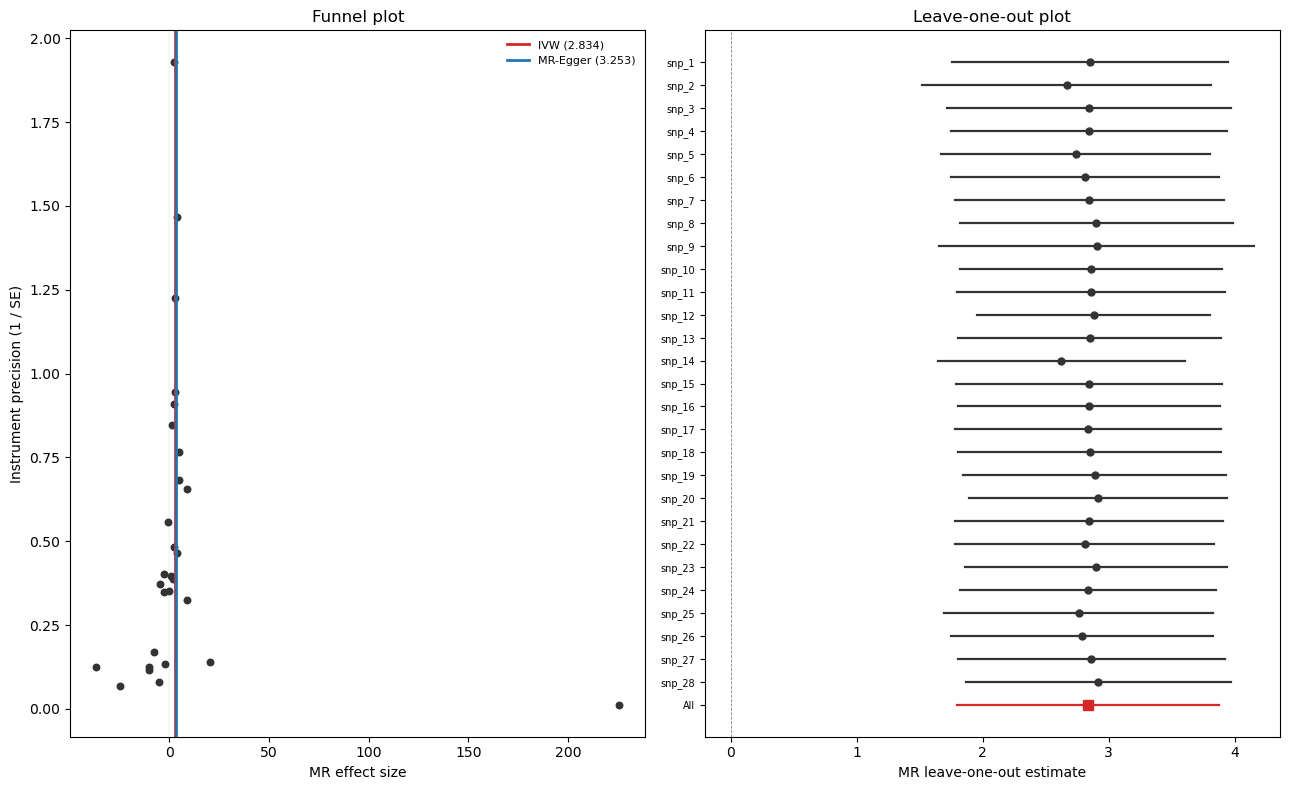

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 8))
mr.mr_funnel(obj, ax=axes[0])
mr.mr_loo(obj, ax=axes[1])
plt.tight_layout()
plt.show()

## 8. Diagnostics: heterogeneity, pleiotropy, leave-one-out

In [9]:
print("Heterogeneity (Cochran's Q):")
print(mr.mr_heterogeneity(obj).to_string(index=False))
print()
print("Directional-pleiotropy test (MR-Egger intercept):")
print(mr.mr_pleiotropy_test(obj).to_string(index=False))
print()
print("mr_allmethods panel:")
print(mr.mr_allmethods(obj, method="main").to_string(index=False))

Heterogeneity (Cochran's Q):
                   method         Q  Q_df       Q_pval
Inverse variance weighted 99.530426    27 3.073695e-10
                 MR Egger 97.397505    26 3.463692e-10

Directional-pleiotropy test (MR-Egger intercept):
 egger_intercept       se     pval
       -0.011461 0.015188 0.450506

mr_allmethods panel:


         Method  Estimate  Std Error   CILower  CIUpper      P-value
  Simple median  1.755138   0.752693  0.279886 3.230390 1.971067e-02
Weighted median  2.682883   0.416425  1.866705 3.499061 1.173999e-10
            IVW  2.834214   0.529799  1.795826 3.872602 8.815013e-08
       MR-Egger  3.252890   0.770129  1.743465 4.762316 2.401915e-05
    (intercept) -0.011461   0.015188 -0.041229 0.018308 4.505065e-01


## Summary

`py-twosamplemr` reproduces `MendelianRandomization` 0.10.0 to high numerical
precision on identical input. The closed-form estimators are bit-exact; the
maximum-likelihood estimator matches R despite R's `optim` Nelder-Mead
converging to a non-global local point, because py-twosamplemr ships a
line-for-line port of R's `nmmin` C optimiser. Bootstrap-based estimators
agree in their point estimates exactly and in their SEs up to Monte-Carlo
error.